In [1]:
import tensorflow as tf
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Adjusting D_MODEL to 130 to be divisible by 5 heads.
Defined Muscle Groups (Indices): {'Finger Flexors': [2, 3], 'Finger Extensors': [4, 5], 'Wrist Flex/Dev': [1], 'Wrist Extend/Dev': [6, 7], 'Thumb': [0]}
Loading data from: s4_full.mat
Data loaded successfully.
Preprocessing data (No explicit filtering)...
Fitting scalers...
Scalers fitted.
Creating sequences from 35 valid trials...
Created 133000 sequences from 35 trials.
Train size: 106400, Validation size: 26600
Building MHA model...
MHA models built successfully.

--- Training Model Summary ---
Model: "Finger_MHA_Training_Model"
______________________________________________________________________________________________________________________________________________________
 Layer (type)                                    Output Shape                     Param #           Connected to                                      
 emg_input (InputLayer)                          [(None, 200, 8)]                 0                 []     

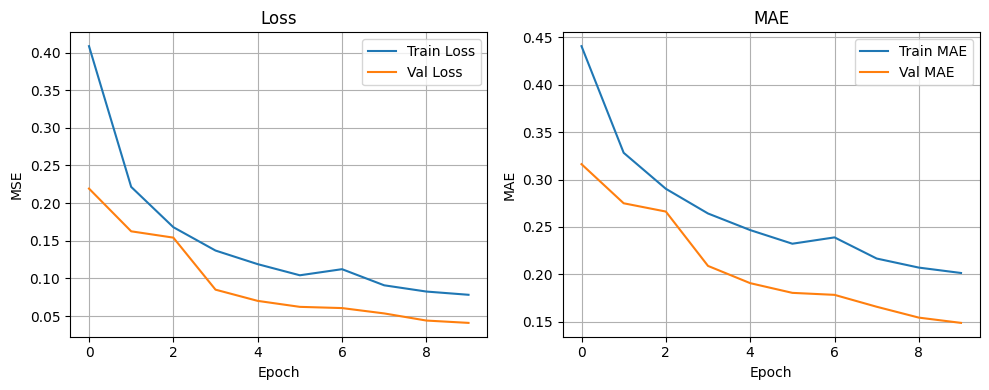


--- Performance Evaluation on Validation Set ---
832/832 [==============================] - 9s 10ms/step
Average R2 Score: 0.960
Average CC Score: 0.981


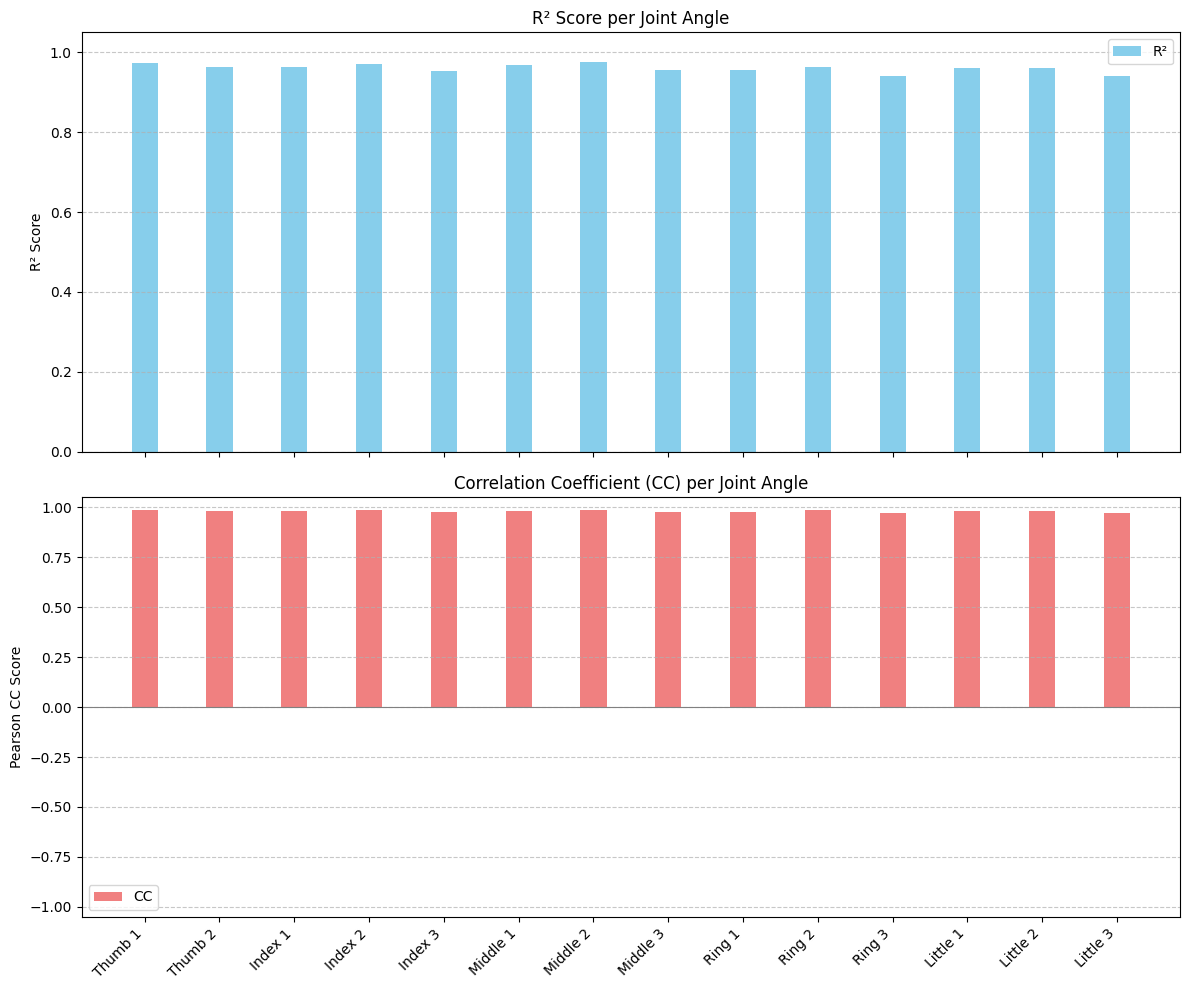

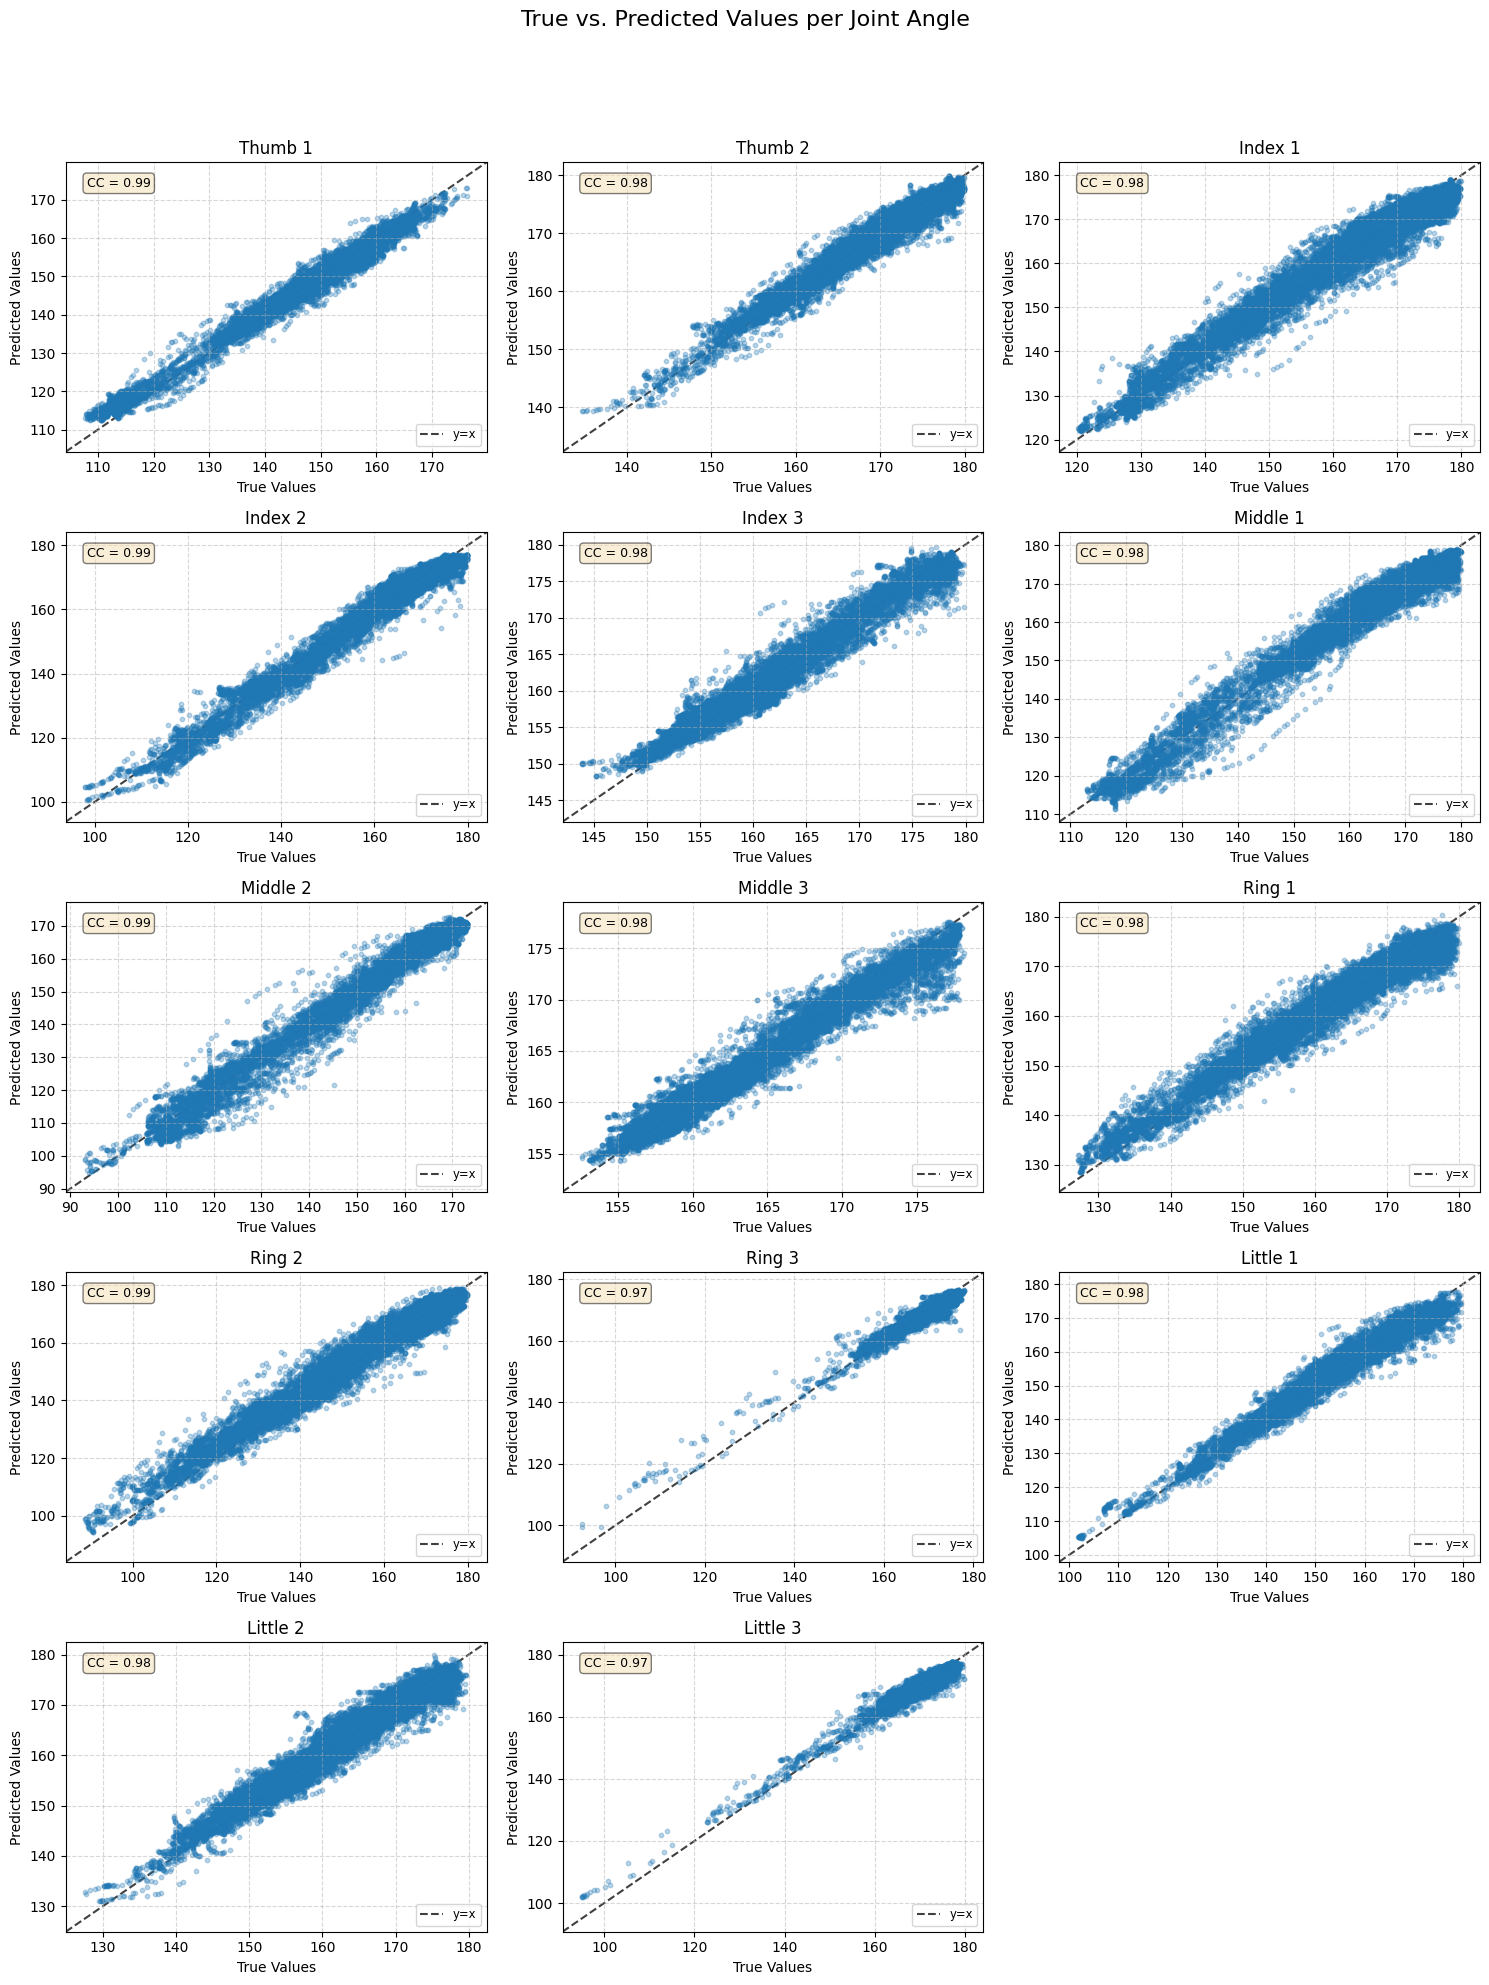


--- Detailed MHA Attention Visualization (Sample Windows) ---
Visualizing MHA attention heatmaps for the first 2 validation sample windows...

--- Visualizing MHA Attention Heatmap for Sample Window Index 0 ---


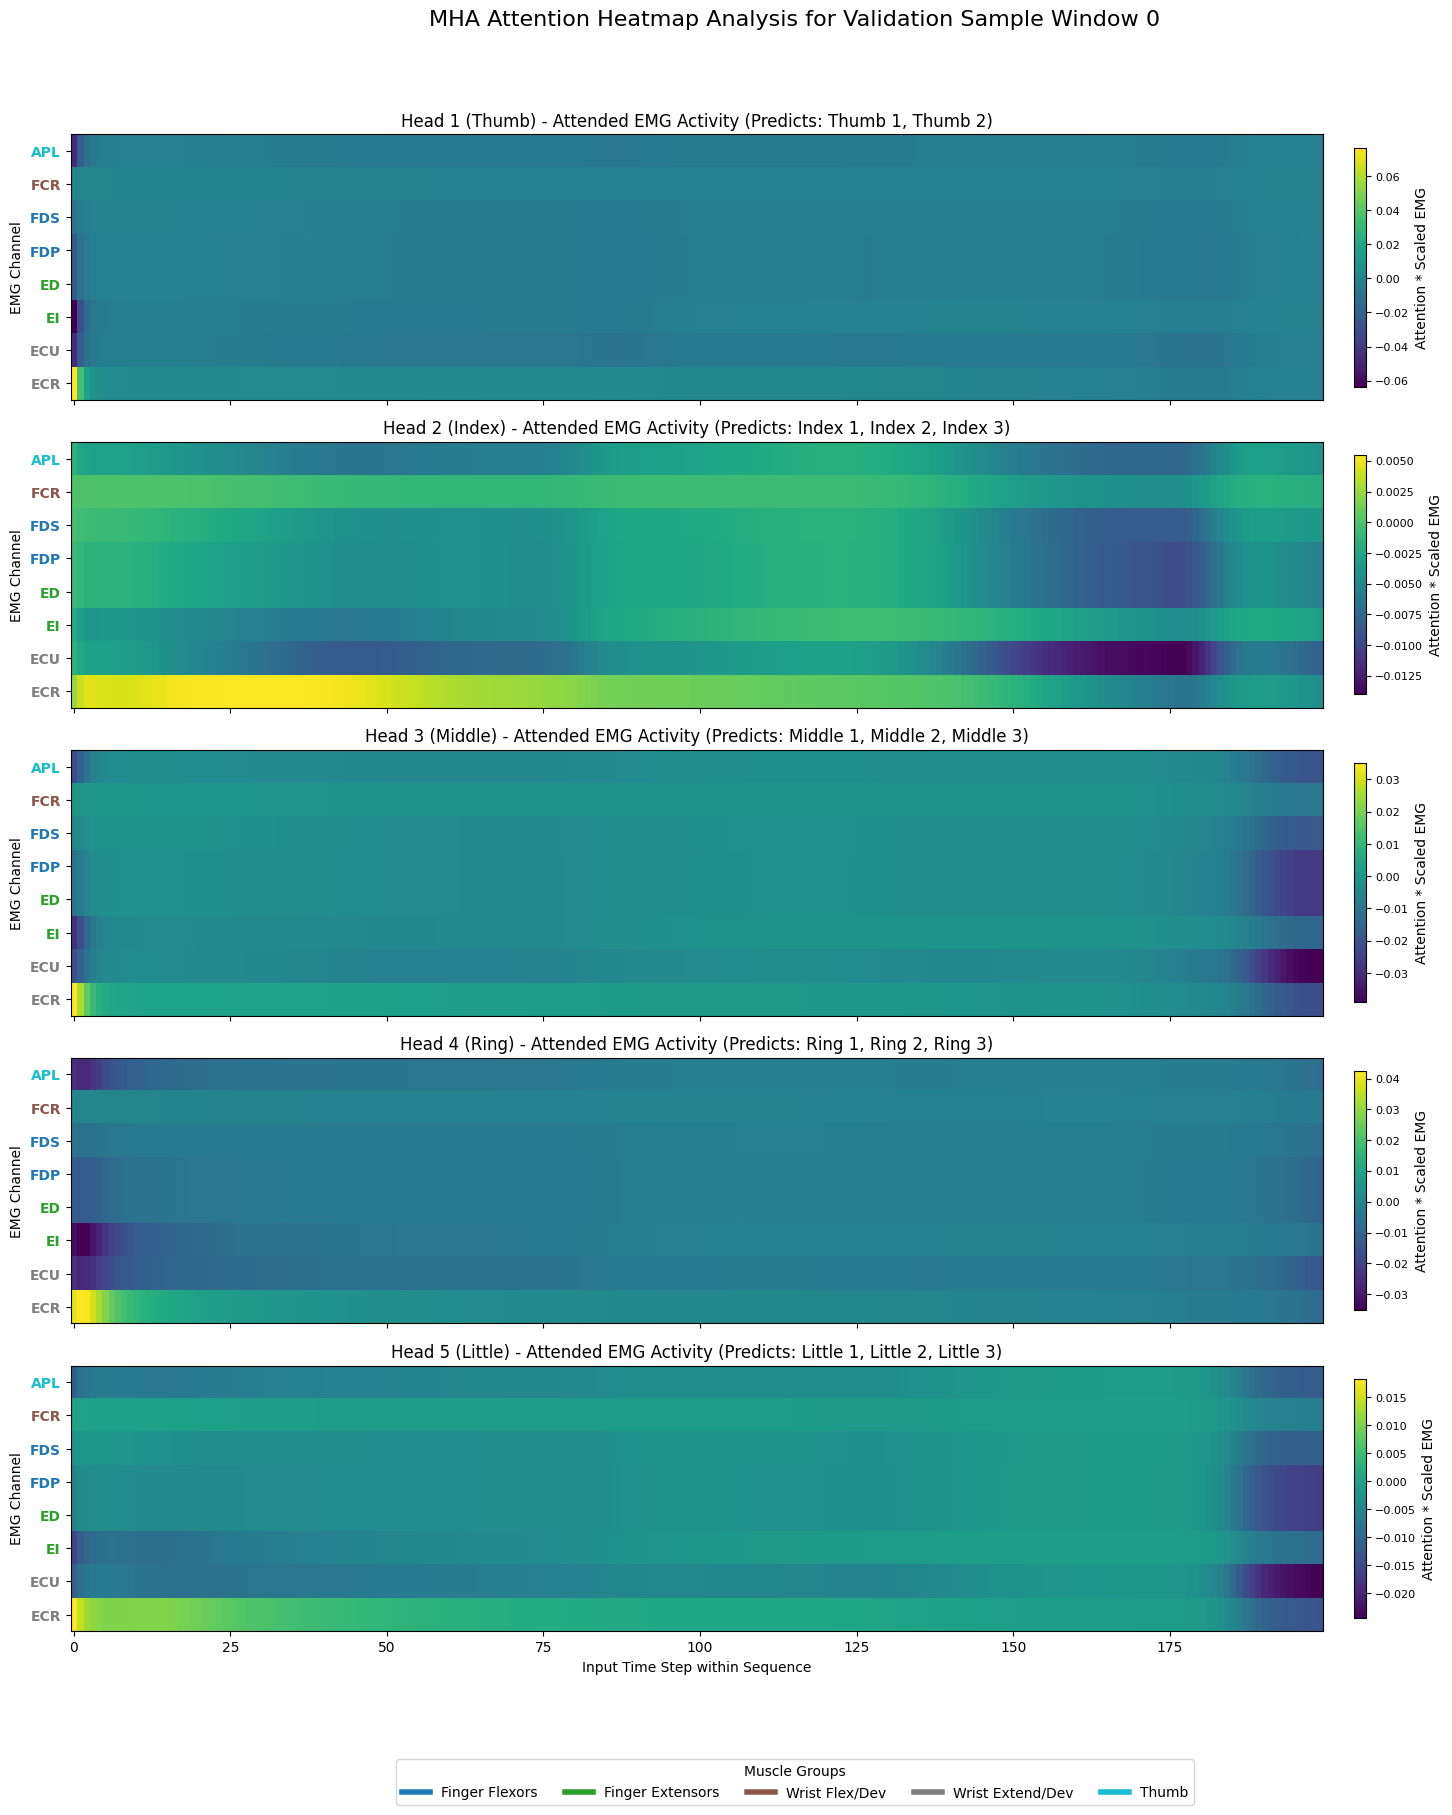


--- Visualizing MHA Attention Heatmap for Sample Window Index 1 ---


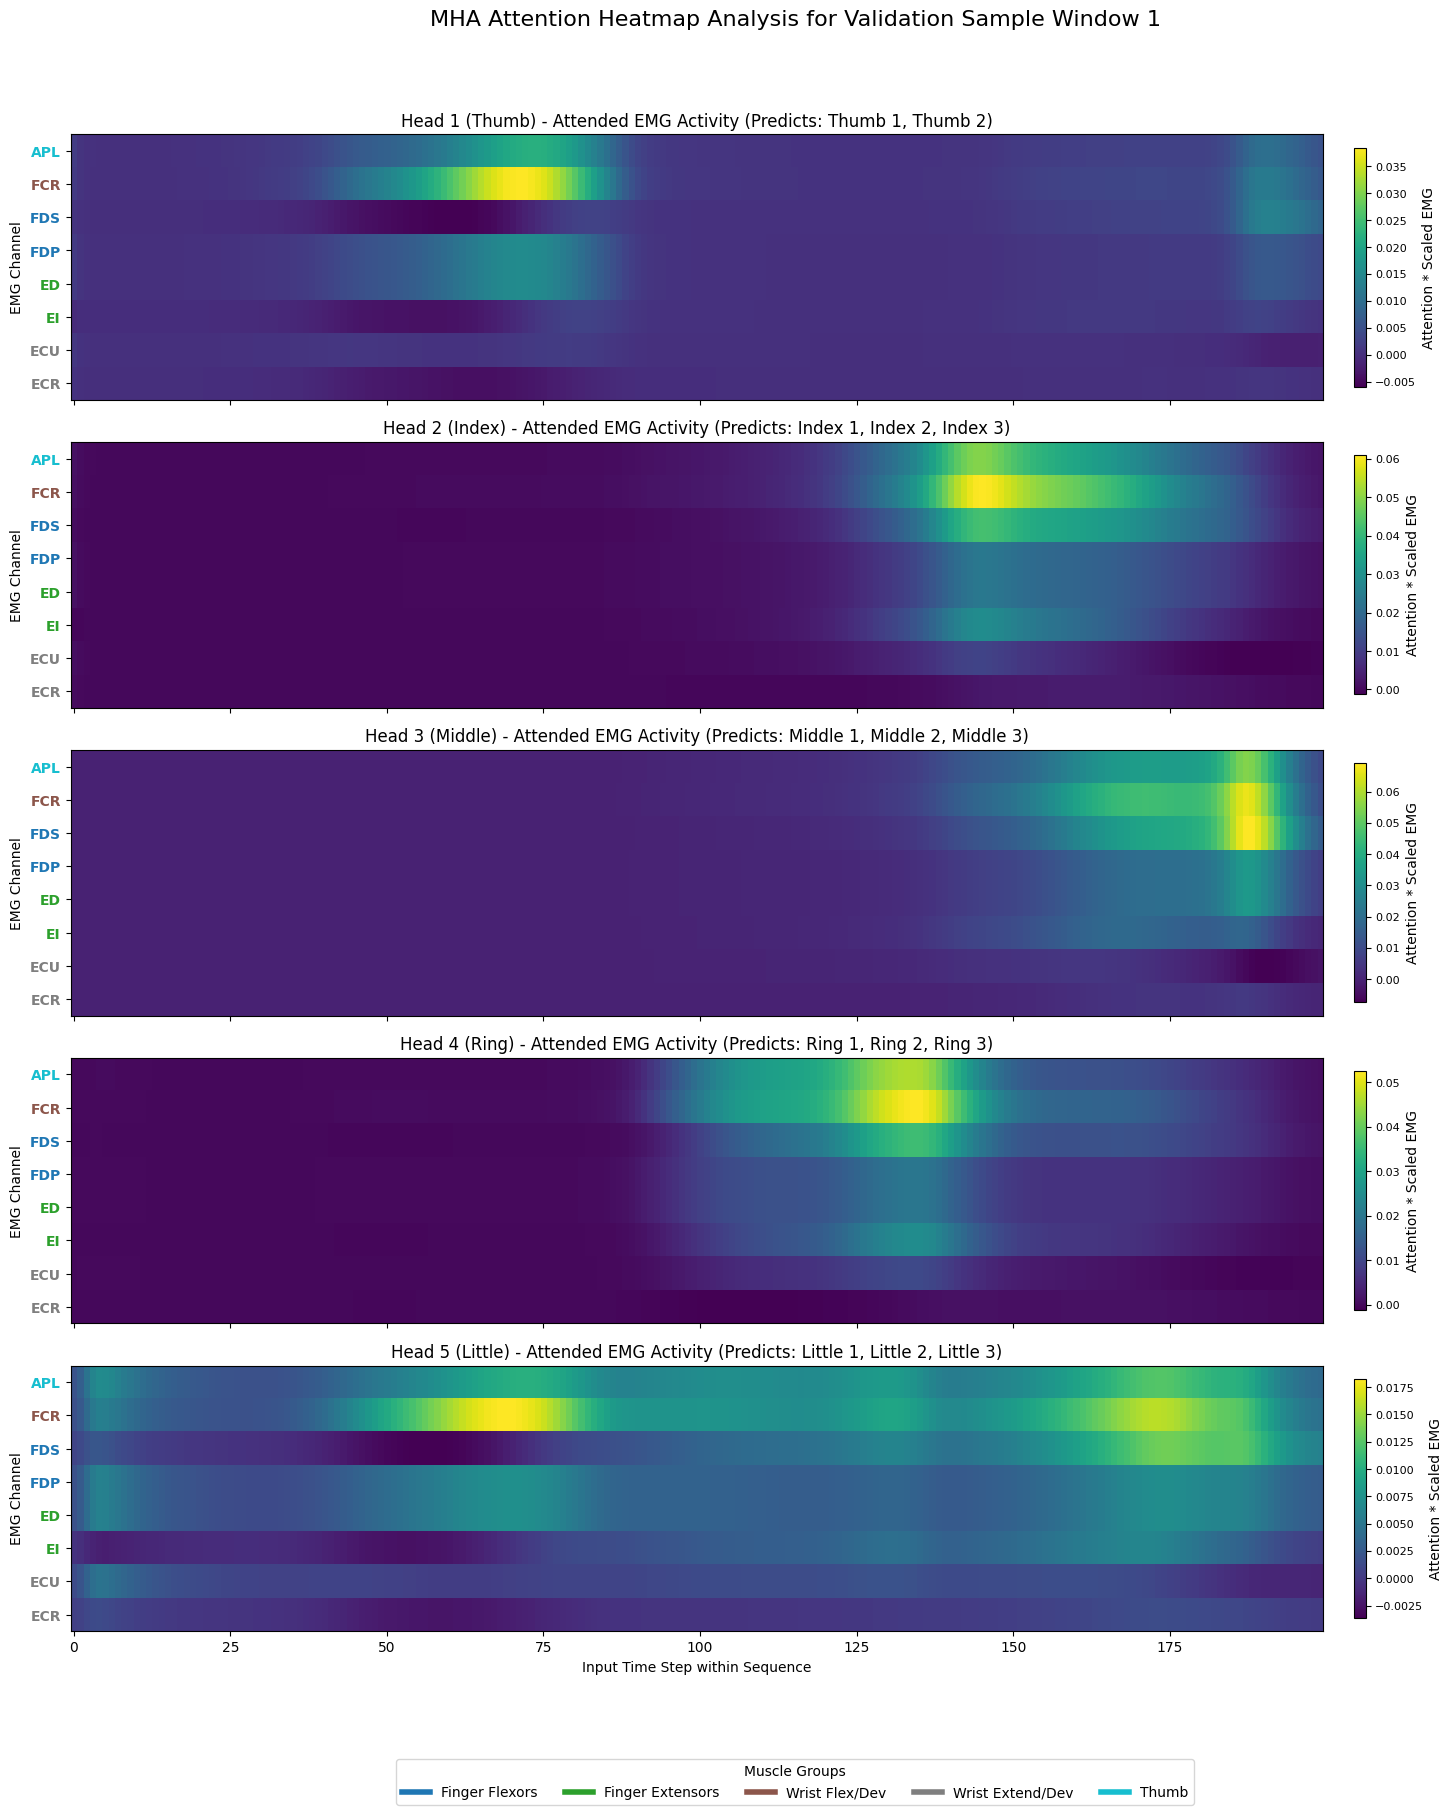


--- Dynamic Trial Simulation Visualization (EMG/Angle/Attention) ---
Visualizing dynamics simulation for the first 1 original trials...

--- Plotting Dynamics Simulation for Trial: T1_Task1 ---
Running model prediction for simulation...


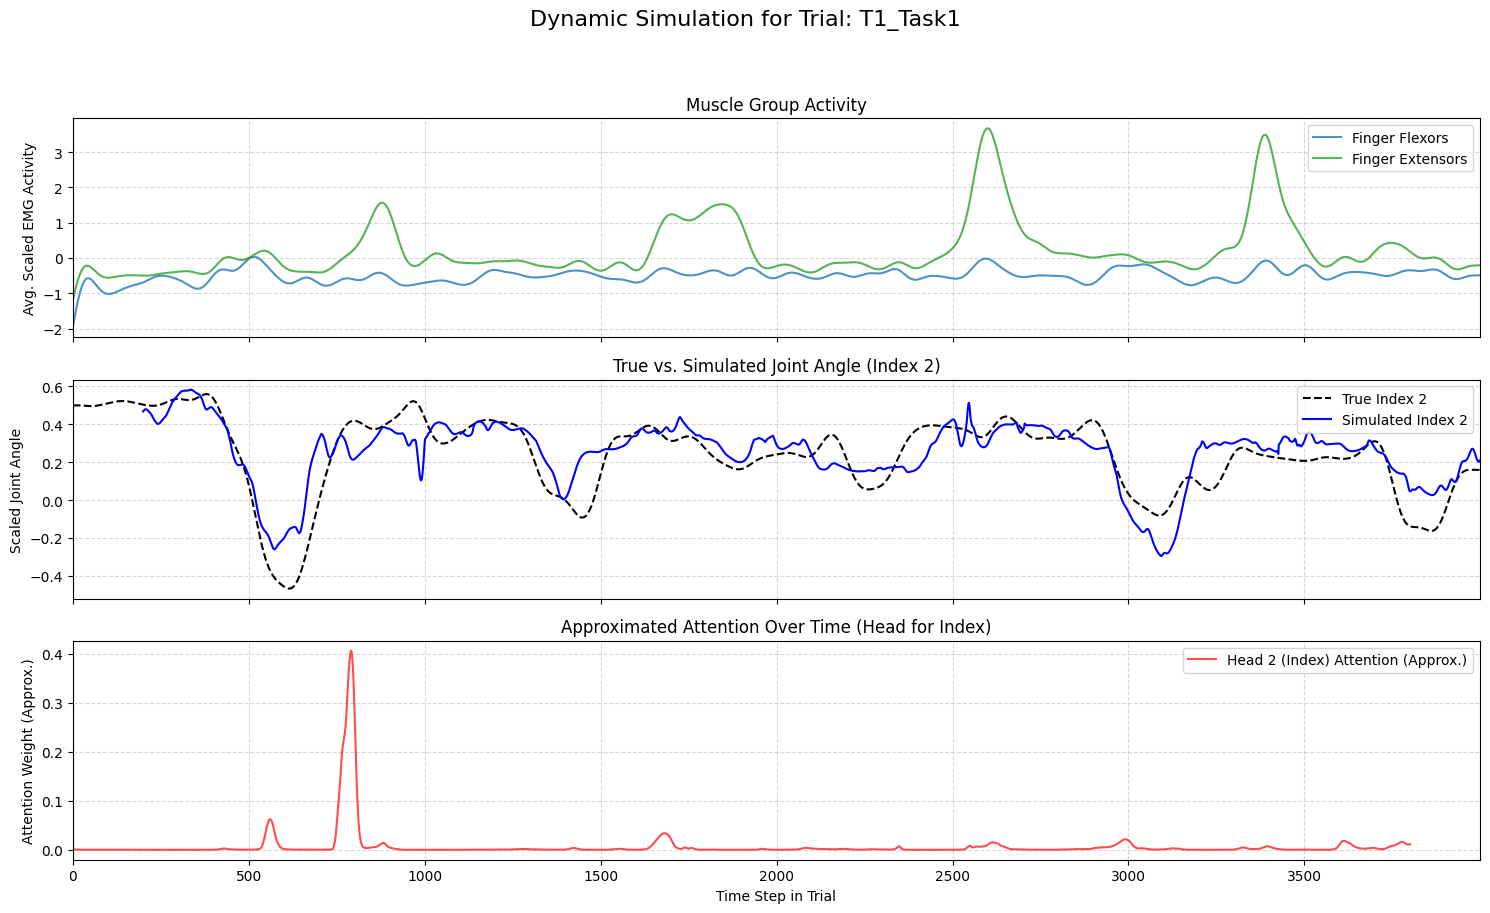


--- Integrated Gradients XAI Visualization ---
Calculating Integrated Gradients for the first 2 validation sample(s)...

--- Explaining Sample Index 0 ---
Explaining prediction for: Index 2 (Index 3)


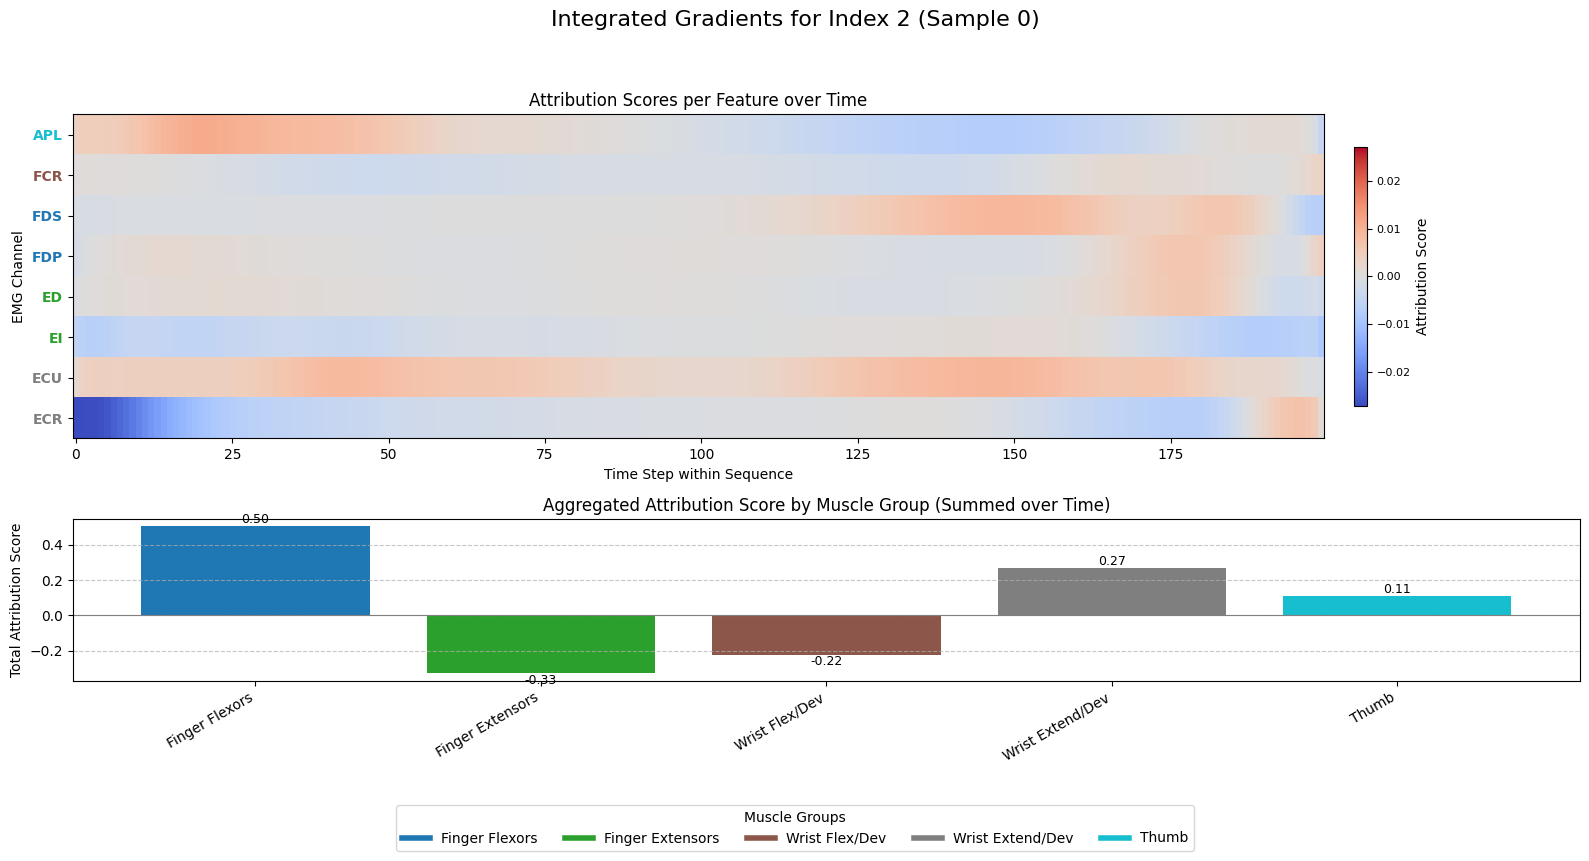


--- Explaining Sample Index 1 ---
Explaining prediction for: Index 2 (Index 3)


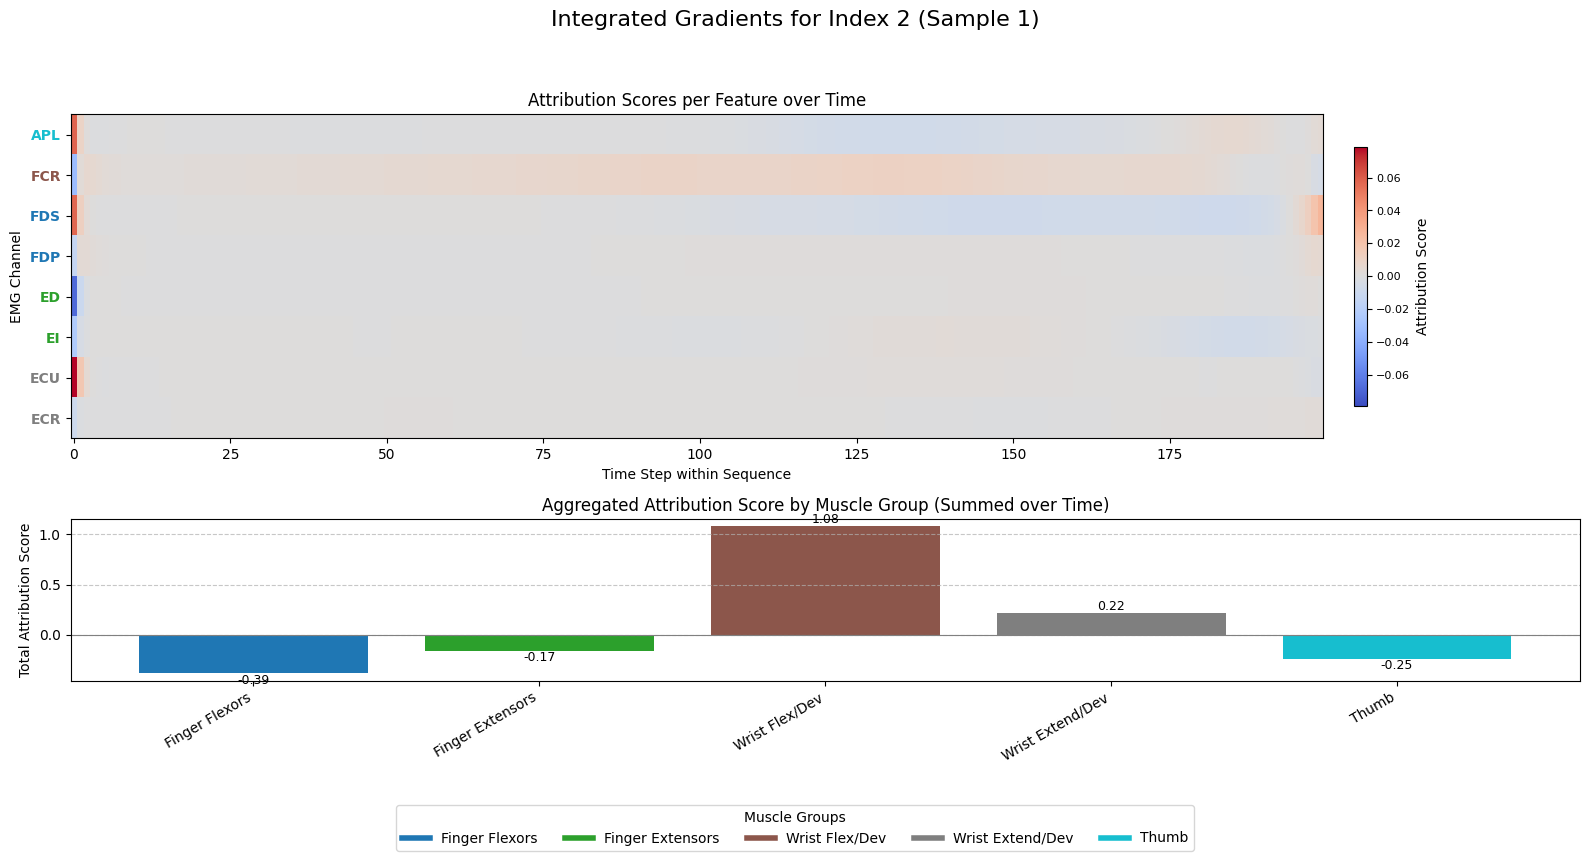

In [ ]:
# -*- coding: utf-8 -*-
"""
Python script for predicting finger kinematics from EMG using a
Multi-Head Attention (MHA) LSTM model with specific EMG preprocessing
and Integrated Gradients for XAI.

Includes:
- Custom MHA model with separate finger heads.
- R2/CC score plotting.
- Regression correlation scatter plots.
- MHA Attention Heatmap visualization (per head, normalized).
- Dynamic Simulation plot (EMG/True Angle/Predicted Angle/Attention).
- Integrated Gradients calculation and visualization.

"""

import numpy as np
import scipy.io
import scipy.stats
# Removed: from scipy.signal import butter, sosfiltfilt # For filtering
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Layer, Dropout, Lambda, LayerNormalization, MultiHeadAttention,
    Concatenate
)
from tensorflow.keras import backend as K
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import r2_score
import os
import warnings
import math

# --- Configuration ---
MAT_FILE_PATH = 's4_full.mat' # <<<--- Example path, UPDATE FOR COLAB
SEQUENCE_LENGTH = 200
PREDICTION_HORIZON = 1 # Keep as 1 for current model structure
BATCH_SIZE = 128
EPOCHS = 10 # Adjust as needed
LSTM_UNITS = 128
VALIDATION_SPLIT = 0.2
MAX_SAMPLES_TO_VIZ_MHA = 2 # Limit detailed MHA heatmap visualization output
NUM_TRIALS_TO_PLOT_DYNAMICS = 1 # Limit dynamic plot output
NUM_SAMPLES_FOR_XAI = 2 # How many samples to run XAI (IG) on

# EMG Preprocessing Config - Filter parameters removed
# FS = 200.0
# LOWCUT = 20.0
# HIGHCUT = 95.0
# FILTER_ORDER = 4

# MHA Configuration
NUM_ATTENTION_HEADS = 5
D_MODEL = LSTM_UNITS
if D_MODEL % NUM_ATTENTION_HEADS != 0:
     D_MODEL = math.ceil(D_MODEL / NUM_ATTENTION_HEADS) * NUM_ATTENTION_HEADS
     print(f"Adjusting D_MODEL to {D_MODEL} to be divisible by {NUM_ATTENTION_HEADS} heads.")

# Integrated Gradients Config
IG_STEPS = 50 # Number of steps for approximation

# EMG Channel Names
EMG_CHANNEL_NAMES = ['APL', 'FCR', 'FDS', 'FDP', 'ED', 'EI', 'ECU', 'ECR']
# Joint Angle Names
JOINT_ANGLE_NAMES = [
    'Thumb 1', 'Thumb 2', 'Index 1', 'Index 2', 'Index 3', 'Middle 1', 'Middle 2', 'Middle 3',
    'Ring 1', 'Ring 2', 'Ring 3', 'Little 1', 'Little 2', 'Little 3'
]
# Finger to Joint Mapping
FINGER_JOINT_INDICES = {
    'Thumb': list(range(0, 2)), 'Index': list(range(2, 5)), 'Middle': list(range(5, 8)),
    'Ring': list(range(8, 11)), 'Little': list(range(11, 14))
}
FINGER_NAMES = list(FINGER_JOINT_INDICES.keys())

# --- Muscle Group Definitions ---
MUSCLE_GROUPS = {
    'Finger Flexors': [EMG_CHANNEL_NAMES.index('FDS'), EMG_CHANNEL_NAMES.index('FDP')],
    'Finger Extensors': [EMG_CHANNEL_NAMES.index('ED'), EMG_CHANNEL_NAMES.index('EI')],
    'Wrist Flex/Dev': [EMG_CHANNEL_NAMES.index('FCR')],
    'Wrist Extend/Dev': [EMG_CHANNEL_NAMES.index('ECU'), EMG_CHANNEL_NAMES.index('ECR')],
    'Thumb': [EMG_CHANNEL_NAMES.index('APL')]
}
# Assign colors
try: cmap = plt.colormaps.get_cmap('tab10')
except AttributeError: cmap = plt.cm.get_cmap('tab10')
GROUP_COLORS = cmap(np.linspace(0, 1, len(MUSCLE_GROUPS)))
MUSCLE_GROUP_VIS_INFO = {name: {'indices': indices, 'color': GROUP_COLORS[i]}
                         for i, (name, indices) in enumerate(MUSCLE_GROUPS.items())}
print("Defined Muscle Groups (Indices):", MUSCLE_GROUPS)

# --- Custom Multi-Head Attention Layer ---
# (Definition remains the same as previous version)
class CustomMultiHeadAttentionSeparateOutput(Layer):
    """ Custom MHA layer returning separate context vectors per head. """
    def __init__(self, num_heads, d_model, **kwargs):
        super().__init__(**kwargs)
        if d_model % num_heads != 0: raise ValueError(f"d_model ({d_model}) must be divisible by num_heads ({num_heads})")
        self.num_heads = num_heads; self.d_model = d_model; self.depth = d_model // num_heads
        self.wq = Dense(d_model, name='q_proj'); self.wk = Dense(d_model, name='k_proj'); self.wv = Dense(d_model, name='v_proj')

    def split_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def scaled_dot_product_attention(self, q, k, v, mask=None):
        matmul_qk = tf.matmul(q, k, transpose_b=True)
        dk = tf.cast(tf.shape(k)[-1], tf.float32)
        scaled_attention_logits = matmul_qk / tf.math.sqrt(dk)
        if mask is not None: scaled_attention_logits += (mask * -1e9)
        attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)
        output = tf.matmul(attention_weights, v)
        return output, attention_weights

    def call(self, query, value, key, mask=None, return_attention_scores=False):
        batch_size = tf.shape(query)[0]
        q = self.wq(query); k = self.wk(key); v = self.wv(value)
        q = self.split_heads(q, batch_size); k = self.split_heads(k, batch_size); v = self.split_heads(v, batch_size)
        scaled_attention, attention_weights = self.scaled_dot_product_attention(q, k, v, mask)
        scaled_attention = tf.transpose(scaled_attention, perm=[0, 2, 1, 3])
        head_outputs = [scaled_attention[:, :, i, :] for i in range(self.num_heads)]
        if query.shape[1] == 1: head_outputs_squeezed = [tf.squeeze(head, axis=1) for head in head_outputs]
        else: head_outputs_squeezed = head_outputs
        squeezed_attention_weights = tf.squeeze(attention_weights, axis=2)
        if return_attention_scores: return head_outputs_squeezed, squeezed_attention_weights
        else: return head_outputs_squeezed

    def get_config(self):
        config = super().get_config()
        config.update({'num_heads': self.num_heads, 'd_model': self.d_model})
        return config

# --- 1. Data Loading ---
def load_mat_data(filepath):
    """Loads EMG and joint angle data from the specified .mat file."""
    print(f"Loading data from: {filepath}")
    if not os.path.exists(filepath): print(f"Error: File not found at {filepath}"); return None, None, None
    try:
        mat_data = scipy.io.loadmat(filepath)
        emg_data_cells = mat_data['dsfilt_emg']
        joint_angles_cells = mat_data['joint_angles']
        kinematics_data = mat_data.get('finger_kinematics', None)
        print("Data loaded successfully.")
        return emg_data_cells, joint_angles_cells, kinematics_data
    except Exception as e: print(f"An error occurred during loading: {e}"); return None, None, None

# --- 2. Data Preprocessing (Filtering Removed) ---
# Removed filter design and application functions

# Removed filter parameters from signature
def preprocess_data(emg_data_cells, joint_angles_cells, sequence_length, prediction_horizon):
    """ Preprocesses data: flattens, creates sequences, normalizes, splits. (No filtering) """
    print("Preprocessing data (No explicit filtering)...")
    all_emg_sequences, all_angle_targets = [], []
    original_scaled_trials = []
    num_trials, num_tasks = emg_data_cells.shape
    emg_scaler, angle_scaler = StandardScaler(), StandardScaler()
    temp_emg_list, temp_angle_list = [], []

    # --- Fit scalers first (on raw data) ---
    print("Fitting scalers...")
    emg_list_for_scaling = [] # Renamed list
    angle_list_for_scaling = []
    valid_trial_count = 0
    for i in range(num_trials):
        for j in range(num_tasks):
            if isinstance(emg_data_cells[i, j], np.ndarray) and emg_data_cells[i, j].ndim == 2 and emg_data_cells[i, j].shape[0] > 0 and \
               isinstance(joint_angles_cells[i, j], np.ndarray) and joint_angles_cells[i, j].ndim == 2 and joint_angles_cells[i, j].shape[0] > 0:
                min_len = min(emg_data_cells[i,j].shape[0], joint_angles_cells[i,j].shape[0])
                if min_len >= sequence_length + prediction_horizon:
                    trial_emg = emg_data_cells[i, j][:min_len, :] # Use raw EMG
                    trial_angle = joint_angles_cells[i, j][:min_len, :]
                    # --- Filtering Removed ---
                    emg_list_for_scaling.append(trial_emg) # Append raw EMG
                    angle_list_for_scaling.append(trial_angle)
                    valid_trial_count += 1

    if not emg_list_for_scaling: print("Error: No valid data/trials long enough found."); return None, None, None, None, None, None, None
    full_emg_data = np.vstack(emg_list_for_scaling); full_angle_data = np.vstack(angle_list_for_scaling)
    if np.any(np.isnan(full_emg_data)) or np.any(np.isinf(full_emg_data)) or \
       np.any(np.isnan(full_angle_data)) or np.any(np.isinf(full_angle_data)): raise ValueError("NaN or Inf detected in data.")
    emg_scaler.fit(full_emg_data); angle_scaler.fit(full_angle_data); print("Scalers fitted.")

    # --- Create sequences and store original scaled trials ---
    print(f"Creating sequences from {valid_trial_count} valid trials...")
    trial_count = 0
    for i in range(num_trials):
        for j in range(num_tasks):
             if isinstance(emg_data_cells[i, j], np.ndarray) and emg_data_cells[i, j].ndim == 2 and emg_data_cells[i, j].shape[0] > 0 and \
               isinstance(joint_angles_cells[i, j], np.ndarray) and joint_angles_cells[i, j].ndim == 2 and joint_angles_cells[i, j].shape[0] > 0:
                min_len = min(emg_data_cells[i,j].shape[0], joint_angles_cells[i,j].shape[0])
                if min_len >= sequence_length + prediction_horizon:
                    trial_emg = emg_data_cells[i, j][:min_len, :] # Raw EMG
                    trial_angle = joint_angles_cells[i, j][:min_len, :]
                    # --- Filtering Removed ---
                    # Scale the full raw trial
                    trial_emg_scaled = emg_scaler.transform(trial_emg) # Scale raw EMG
                    trial_angle_scaled = angle_scaler.transform(trial_angle)
                    original_scaled_trials.append({'emg': trial_emg_scaled, 'angle': trial_angle_scaled, 'id': f"T{i+1}_Task{j+1}"})
                    # Create sequences from this scaled trial
                    for k in range(len(trial_emg_scaled) - sequence_length - prediction_horizon + 1):
                        emg_sequence = trial_emg_scaled[k : k + sequence_length]
                        angle_target = trial_angle_scaled[k + sequence_length : k + sequence_length + prediction_horizon]
                        if prediction_horizon == 1: angle_target = angle_target.squeeze(axis=0)
                        all_emg_sequences.append(emg_sequence); all_angle_targets.append(angle_target)
                    trial_count += 1

    if not all_emg_sequences: print("Error: Could not create sequences."); return None, None, None, None, None, None, None
    X = np.array(all_emg_sequences); y = np.array(all_angle_targets); print(f"Created {X.shape[0]} sequences from {trial_count} trials.")
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=VALIDATION_SPLIT, random_state=42, shuffle=True)
    print(f"Train size: {X_train.shape[0]}, Validation size: {X_val.shape[0]}")
    return X_train, X_val, y_train, y_val, emg_scaler, angle_scaler, original_scaled_trials


# --- 3. Model Architecture (MHA Redesign) ---
# (Definition remains the same as previous version)
def build_finger_mha_lstm(sequence_length, num_emg_features, num_angle_features,
                          lstm_units, d_model, num_heads, finger_joint_indices):
    """ Builds LSTM with Custom MHA and separate finger prediction heads. """
    print("Building MHA model...")
    if num_heads != len(finger_joint_indices): raise ValueError("Number of heads must match number of fingers defined.")
    encoder_inputs = Input(shape=(sequence_length, num_emg_features), name='emg_input')
    encoder_lstm = LSTM(lstm_units, return_sequences=True, return_state=True, name='encoder_lstm')
    if d_model != lstm_units: print(f"Warning: d_model({d_model}) != lstm_units({lstm_units}). Ensure consistency.")
    encoder_outputs, state_h, state_c = encoder_lstm(encoder_inputs)
    encoder_outputs_norm = LayerNormalization(epsilon=1e-6)(encoder_outputs)
    state_h_norm = LayerNormalization(epsilon=1e-6)(state_h)
    query = Lambda(lambda x: tf.expand_dims(x, axis=1), name='expand_query_dim')(state_h_norm)
    value = encoder_outputs_norm; key = encoder_outputs_norm
    mha_layer = CustomMultiHeadAttentionSeparateOutput(num_heads=num_heads, d_model=d_model, name='custom_mha')
    head_context_vectors, attention_weights = mha_layer(query=query, value=value, key=key, return_attention_scores=True)
    finger_outputs = []
    finger_names = list(finger_joint_indices.keys())
    for i in range(num_heads):
        finger_name = finger_names[i]; num_finger_joints = len(finger_joint_indices[finger_name])
        head_context = head_context_vectors[i]
        finger_dense1 = Dense(32, activation='relu', name=f'{finger_name}_dense1')(head_context)
        finger_dropout = Dropout(0.2, name=f'{finger_name}_dropout')(finger_dense1)
        finger_output = Dense(num_finger_joints, activation='linear', name=f'{finger_name}_output')(finger_dropout)
        finger_outputs.append(finger_output)
    final_output = Concatenate(axis=-1, name='final_concatenated_output')(finger_outputs)
    model = Model(inputs=encoder_inputs, outputs=final_output, name='Finger_MHA_Training_Model')
    attention_model = Model(inputs=encoder_inputs, outputs=attention_weights, name='Finger_MHA_Attention_Model')
    print("MHA models built successfully.")
    return model, attention_model

# --- 4. Training ---
# (Definition remains the same as previous version)
def train_model(model, X_train, y_train, X_val, y_val, epochs, batch_size):
    """ Compiles and trains the model. """
    print("Compiling model...")
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    print("Starting training...")
    early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_val, y_val), callbacks=[early_stopping], verbose=1)
    print("Training finished.")
    return history

# --- 5. Performance Evaluation & Visualization ---
# (Definitions remain the same as previous version)
def calculate_performance_scores(y_true, y_pred):
    """ Calculates R2 and CC scores for each output feature. """
    if y_true.shape != y_pred.shape: raise ValueError(f"Shape mismatch: y_true {y_true.shape}, y_pred {y_pred.shape}")
    if y_true.ndim != 2: raise ValueError(f"Expected 2D arrays, got shapes: y_true {y_true.shape}, y_pred {y_pred.shape}")
    num_features = y_true.shape[1]
    r2_scores, cc_scores, cc_pvalues = [], [], []
    for i in range(num_features):
        r2 = r2_score(y_true[:, i], y_pred[:, i])
        r2_scores.append(r2)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", RuntimeWarning)
            cc, p_value = scipy.stats.pearsonr(y_true[:, i], y_pred[:, i])
            if np.isnan(cc): cc, p_value = 0.0, 1.0
        cc_scores.append(cc); cc_pvalues.append(p_value)
    return np.array(r2_scores), np.array(cc_scores), np.array(cc_pvalues)

def plot_performance_scores(r2_scores, cc_scores, angle_names):
    """ Creates bar plots for R2 and CC scores. """
    num_angles = len(angle_names); x = np.arange(num_angles); width = 0.35
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    rects1 = ax1.bar(x, r2_scores, width, label='R²', color='skyblue')
    ax1.set_ylabel('R² Score'); ax1.set_title('R² Score per Joint Angle')
    ax1.set_ylim(min(0, np.min(r2_scores)-0.1 if r2_scores.size > 0 else 0), 1.05); ax1.axhline(0, color='grey', lw=0.8)
    ax1.legend(); ax1.grid(axis='y', linestyle='--', alpha=0.7)
    rects2 = ax2.bar(x, cc_scores, width, label='CC', color='lightcoral')
    ax2.set_ylabel('Pearson CC Score'); ax2.set_title('Correlation Coefficient (CC) per Joint Angle')
    ax2.set_xticks(x); ax2.set_xticklabels(angle_names, rotation=45, ha='right')
    ax2.set_ylim(-1.05, 1.05); ax2.axhline(0, color='grey', lw=0.8)
    ax2.legend(); ax2.grid(axis='y', linestyle='--', alpha=0.7)
    fig.tight_layout(); plt.show()

def plot_regression_correlation(y_true, y_pred, angle_names, cc_scores=None):
    """ Creates scatter plots for true vs predicted values for each angle. """
    num_angles = y_true.shape[1]
    if num_angles != len(angle_names): angle_names = [f"Angle {i+1}" for i in range(num_angles)]
    ncols = 3; nrows = math.ceil(num_angles / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), sharex=False, sharey=False)
    axes = axes.flatten()
    for i in range(num_angles):
        ax = axes[i]; true_vals = y_true[:, i]; pred_vals = y_pred[:, i]
        ax.scatter(true_vals, pred_vals, alpha=0.3, s=10)
        min_val = min(np.min(true_vals), np.min(pred_vals)); max_val = max(np.max(true_vals), np.max(pred_vals))
        padding = (max_val - min_val) * 0.05; lims = [min_val - padding, max_val + padding]
        ax.plot(lims, lims, 'k--', alpha=0.75, zorder=0, label='y=x'); ax.set_xlim(lims); ax.set_ylim(lims)
        ax.set_xlabel("True Values"); ax.set_ylabel("Predicted Values"); ax.set_title(f"{angle_names[i]}")
        ax.grid(True, linestyle='--', alpha=0.5)
        if cc_scores is not None and i < len(cc_scores): cc = cc_scores[i]; ax.text(0.05, 0.95, f'CC = {cc:.2f}', transform=ax.transAxes, fontsize=9, va='top', bbox=dict(boxstyle='round,pad=0.3', fc='wheat', alpha=0.5))
        ax.legend(loc='lower right', fontsize='small')
    for j in range(num_angles, len(axes)): fig.delaxes(axes[j])
    fig.suptitle("True vs. Predicted Values per Joint Angle", fontsize=16, y=1.02)
    fig.tight_layout(rect=[0, 0.03, 1, 0.98]); plt.show()


# --- 6. Attention Visualization (MHA Redesign - Updated) ---
# (Definitions remain the same as previous version)
def get_mha_attention_weights(input_data, attention_model):
    """ Extracts MHA attention weights (batch, heads, seq_len). """
    try:
        input_data_float32 = input_data.astype(np.float32)
        attention_weights = attention_model.predict(input_data_float32, verbose=0)
        return attention_weights
    except Exception as e: print(f"Error during MHA attention weight prediction: {e}"); return None

def plot_mha_attention_heatmap(input_emg_sequence, attention_weights_sample,
                               emg_channels, muscle_group_info, finger_names,
                               title="MHA Attention Analysis"):
    """ Plots one heatmap per head showing attended EMG activity (Normalized Per Head). """
    num_heads, seq_len = attention_weights_sample.shape
    num_emg = len(emg_channels)
    if input_emg_sequence is None or input_emg_sequence.shape != (seq_len, num_emg): print(f"Cannot plot: Input EMG sequence shape mismatch or is None."); return

    fig, axes = plt.subplots(num_heads, 1, figsize=(16, 3.5 * num_heads), sharex=True)
    if num_heads == 1: axes = [axes]
    fig.suptitle(title, fontsize=16, y=1.01)
    heatmap_data = np.zeros((num_heads, num_emg, seq_len))
    for h in range(num_heads):
        for t in range(seq_len):
            for c in range(num_emg): heatmap_data[h, c, t] = attention_weights_sample[h, t] * input_emg_sequence[t, c]
    for h in range(num_heads):
        ax = axes[h]; head_data = heatmap_data[h, :, :]
        vmin_head = np.min(head_data); vmax_head = np.max(head_data)
        if abs(vmax_head - vmin_head) < 1e-6: vmin_head -= 0.01; vmax_head += 0.01
        im = ax.imshow(head_data, aspect='auto', cmap='viridis', vmin=vmin_head, vmax=vmax_head)
        ax.set_yticks(np.arange(num_emg)); ax.set_yticklabels(emg_channels)
        ax.set_title(f"Head {h+1} ({finger_names[h]}) - Attended EMG Activity (Predicts: {', '.join(JOINT_ANGLE_NAMES[idx] for idx in FINGER_JOINT_INDICES[finger_names[h]])})")
        ax.set_ylabel("EMG Channel")
        for group_name, info in muscle_group_info.items():
            for idx in info['indices']:
                if 0 <= idx < len(ax.get_yticklabels()): ax.get_yticklabels()[idx].set_color(info['color']); ax.get_yticklabels()[idx].set_fontweight('bold')
        cbar = fig.colorbar(im, ax=ax, label='Attention * Scaled EMG', shrink=0.9, pad=0.02); cbar.ax.tick_params(labelsize=8)
    axes[-1].set_xlabel("Input Time Step within Sequence")
    legend_elements = [plt.Line2D([0], [0], color=info['color'], lw=4, label=name) for name, info in muscle_group_info.items()]
    fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=len(muscle_group_info), title="Muscle Groups")
    plt.tight_layout(rect=[0, 0.05, 1, 0.98]); plt.show()

# --- 7. Dynamic EMG/Angle Simulation Plot ---
# (Definition modified from previous version)
def plot_trial_dynamics_simulation(
    trial_emg_scaled, trial_angles_scaled, # True angle data for comparison
    model, attention_model, # Trained models
    emg_channels, joint_angle_names, muscle_group_info,
    finger_names, finger_joint_indices, sequence_length,
    prediction_horizon, # <<<--- Argument added
    trial_id="Unknown Trial"):
    """ Visualizes EMG group activity, true vs. SIMULATED joint angles, and approximated attention. """
    print(f"\n--- Plotting Dynamics Simulation for Trial: {trial_id} ---")
    trial_len = trial_emg_scaled.shape[0]
    if trial_len < sequence_length: print(f"Trial too short ({trial_len} steps). Skipping dynamics plot."); return

    num_windows = trial_len - sequence_length + 1
    X_windows = np.array([trial_emg_scaled[k:k + sequence_length] for k in range(num_windows)])
    X_windows_float32 = X_windows.astype(np.float32)
    mha_attention_weights = get_mha_attention_weights(X_windows_float32, attention_model)
    if mha_attention_weights is None: print("Could not get attention weights. Skipping."); return
    print("Running model prediction for simulation...")
    y_pred_windows_scaled = model.predict(X_windows_float32, verbose=0)
    # print(f"Predicted angles shape: {y_pred_windows_scaled.shape}") # Verbose
    num_heads = mha_attention_weights.shape[1]
    groups_to_plot = ['Finger Flexors', 'Finger Extensors']
    group_indices_to_plot = {name: muscle_group_info[name]['indices'] for name in groups_to_plot}
    group_colors_to_plot = {name: muscle_group_info[name]['color'] for name in groups_to_plot}
    angle_name_to_plot = 'Index 2'; angle_idx_to_plot = JOINT_ANGLE_NAMES.index(angle_name_to_plot) if angle_name_to_plot in JOINT_ANGLE_NAMES else 0; angle_name_to_plot = JOINT_ANGLE_NAMES[angle_idx_to_plot]
    head_idx_to_plot = -1; head_name_to_plot = "N/A"
    for head_i, (finger, indices) in enumerate(FINGER_JOINT_INDICES.items()):
        if angle_idx_to_plot in indices: head_idx_to_plot = head_i; head_name_to_plot = finger; break
    if head_idx_to_plot == -1: head_idx_to_plot = 0; head_name_to_plot = finger_names[0]
    attention_over_time = mha_attention_weights[:, head_idx_to_plot, 0]
    attention_time_axis = np.arange(num_windows)
    fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True); fig.suptitle(f"Dynamic Simulation for Trial: {trial_id}", fontsize=16, y=1.01)
    time_axis_full = np.arange(trial_len)
    # Use prediction_horizon in time axis calculation
    time_axis_pred = np.arange(sequence_length + prediction_horizon -1, trial_len + prediction_horizon)
    if len(time_axis_pred) != num_windows: time_axis_pred = np.arange(sequence_length, trial_len + prediction_horizon); # Try adjusting if P_H > 1 caused mismatch
    if len(time_axis_pred) != num_windows: time_axis_pred = None # Give up if still mismatch
    ax1 = axes[0]
    for name, indices in group_indices_to_plot.items():
        if indices: group_activity = np.mean(trial_emg_scaled[:, indices], axis=1); ax1.plot(time_axis_full, group_activity, label=name, color=group_colors_to_plot[name], alpha=0.8)
    ax1.set_ylabel("Avg. Scaled EMG Activity"); ax1.set_title("Muscle Group Activity"); ax1.legend(loc='upper right'); ax1.grid(True, linestyle='--', alpha=0.5)
    ax2 = axes[1]
    ax2.plot(time_axis_full, trial_angles_scaled[:, angle_idx_to_plot], label=f'True {angle_name_to_plot}', color='black', linestyle='--')
    if time_axis_pred is not None and len(time_axis_pred) == y_pred_windows_scaled.shape[0]: ax2.plot(time_axis_pred, y_pred_windows_scaled[:, angle_idx_to_plot], label=f'Simulated {angle_name_to_plot}', color='blue', linestyle='-')
    else: print(f"Cannot plot simulated angle due to time axis mismatch.")
    ax2.set_ylabel("Scaled Joint Angle"); ax2.set_title(f"True vs. Simulated Joint Angle ({angle_name_to_plot})"); ax2.legend(loc='upper right'); ax2.grid(True, linestyle='--', alpha=0.5)
    ax3 = axes[2]
    if len(attention_time_axis) == len(attention_over_time): ax3.plot(attention_time_axis, attention_over_time, label=f'Head {head_idx_to_plot+1} ({head_name_to_plot}) Attention (Approx.)', color='red', alpha=0.7)
    else: print(f"Cannot plot attention: Time axis length mismatch.")
    ax3.set_ylabel("Attention Weight (Approx.)"); ax3.set_title(f"Approximated Attention Over Time (Head for {head_name_to_plot})"); ax3.set_xlabel("Time Step in Trial"); ax3.legend(loc='upper right'); ax3.grid(True, linestyle='--', alpha=0.5); ax3.set_xlim(0, trial_len -1)
    plt.tight_layout(rect=[0, 0, 1, 0.97]); plt.show()


# --- 8. Integrated Gradients XAI (NEW) ---
# (Definitions remain the same as previous version)
@tf.function
def get_gradients(model, input_tensor, target_angle_index):
    """Calculates gradients of the target output angle w.r.t. input tensor."""
    input_tensor = tf.cast(input_tensor, dtype=tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(input_tensor)
        predictions = model(input_tensor, training=False)
        target_output = predictions[:, target_angle_index]
    gradients = tape.gradient(target_output, input_tensor)
    return gradients

def get_integrated_gradients(model, baseline, input_sample, target_angle_index, num_steps=50):
    """Calculates Integrated Gradients attributions."""
    input_sample = tf.convert_to_tensor(input_sample, dtype=tf.float32)
    if baseline is None: baseline = tf.zeros_like(input_sample)
    else: baseline = tf.convert_to_tensor(baseline, dtype=tf.float32)
    if input_sample.shape != baseline.shape: raise ValueError(f"Input shape {input_sample.shape} != baseline shape {baseline.shape}")
    interpolated_inputs = tf.stack([baseline + (float(i) / num_steps) * (input_sample - baseline) for i in range(num_steps + 1)])
    if input_sample.shape[0] == 1: interpolated_inputs = tf.squeeze(interpolated_inputs, axis=1)
    try:
        grads = get_gradients(model, interpolated_inputs, target_angle_index)
        if grads is None: print("Error: Gradients are None."); return None
    except Exception as e:
        print(f"Error calculating gradients during IG: {e}")
        try: # Retry without tf.function
            print("Retrying gradient calculation without tf.function...")
            grads = get_gradients.__wrapped__(model, interpolated_inputs, target_angle_index)
            if grads is None: print("Error: Gradients are still None."); return None
        except Exception as e2: print(f"Error calculating gradients during IG (retry): {e2}"); return None
    grads = (grads[:-1] + grads[1:]) / 2.0
    avg_grads = tf.reduce_mean(grads, axis=0)
    input_squeezed = tf.squeeze(input_sample, axis=0) if input_sample.shape[0] == 1 else input_sample
    baseline_squeezed = tf.squeeze(baseline, axis=0) if baseline.shape[0] == 1 else baseline
    integrated_gradients = (input_squeezed - baseline_squeezed) * avg_grads
    return integrated_gradients.numpy()

def visualize_attributions(attributions, emg_channels, muscle_group_info, title="Feature Attributions"):
    """Visualizes attributions using a heatmap and aggregated bars."""
    seq_len, num_emg = attributions.shape
    fig, axes = plt.subplots(2, 1, figsize=(16, 8), gridspec_kw={'height_ratios': [2, 1]})
    fig.suptitle(title, fontsize=16, y=1.01)
    ax1 = axes[0]; max_abs_val = np.max(np.abs(attributions)); vmin, vmax = -max_abs_val, max_abs_val
    cmap = 'coolwarm'; im = ax1.imshow(attributions.T, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax)
    ax1.set_yticks(np.arange(num_emg)); ax1.set_yticklabels(emg_channels)
    ax1.set_ylabel("EMG Channel"); ax1.set_xlabel("Time Step within Sequence"); ax1.set_title("Attribution Scores per Feature over Time")
    for group_name, info in muscle_group_info.items():
        for idx in info['indices']:
            if 0 <= idx < len(ax1.get_yticklabels()): ax1.get_yticklabels()[idx].set_color(info['color']); ax1.get_yticklabels()[idx].set_fontweight('bold')
    cbar = fig.colorbar(im, ax=ax1, label='Attribution Score', shrink=0.8, pad=0.02); cbar.ax.tick_params(labelsize=8)
    ax2 = axes[1]; group_names = list(muscle_group_info.keys()); total_channel_attribution = np.sum(attributions, axis=0)
    aggregated_scores = {name: 0.0 for name in group_names}
    for group_name, info in muscle_group_info.items():
        if info['indices']: aggregated_scores[group_name] = np.sum(total_channel_attribution[info['indices']])
    x_groups = np.arange(len(group_names)); colors = [muscle_group_info[name]['color'] for name in group_names]
    bars = ax2.bar(x_groups, [aggregated_scores[name] for name in group_names], color=colors)
    ax2.set_ylabel('Total Attribution Score'); ax2.set_title('Aggregated Attribution Score by Muscle Group (Summed over Time)')
    ax2.set_xticks(x_groups); ax2.set_xticklabels(group_names, rotation=30, ha='right')
    ax2.grid(axis='y', linestyle='--', alpha=0.7); ax2.axhline(0, color='grey', lw=0.8)
    for bar in bars: yval = bar.get_height(); ax2.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.2f}', va='bottom' if yval >=0 else 'top', ha='center', fontsize=9)
    legend_elements = [plt.Line2D([0], [0], color=info['color'], lw=4, label=name) for name, info in muscle_group_info.items()]
    fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=len(muscle_group_info), title="Muscle Groups")
    plt.tight_layout(rect=[0, 0.05, 1, 0.97]); plt.show()


# --- Main Execution (Using MHA Model) ---
if __name__ == "__main__":
    # 1. Load Data
    emg_data_cells, joint_angles_cells, _ = load_mat_data(MAT_FILE_PATH)

    if emg_data_cells is not None and joint_angles_cells is not None:
        # 2. Preprocess Data
        # --- MODIFIED CALL: Pass correct variable names ---
        X_train, X_val, y_train, y_val, emg_scaler, angle_scaler, original_scaled_trials = preprocess_data(
            emg_data_cells, joint_angles_cells, SEQUENCE_LENGTH, PREDICTION_HORIZON
            # Removed filter params from call
        )
        # --- End MODIFICATION ---

        if X_train is not None:
            num_emg_features = X_train.shape[2]
            num_angle_features = y_train.shape[1]

            if num_angle_features != len(JOINT_ANGLE_NAMES): exit(f"FATAL Error: Angle features mismatch.")

            # 3. Build MHA Models
            model, attention_model = build_finger_mha_lstm(
                SEQUENCE_LENGTH, num_emg_features, num_angle_features,
                LSTM_UNITS, D_MODEL, NUM_ATTENTION_HEADS, FINGER_JOINT_INDICES
            )
            print("\n--- Training Model Summary ---")
            model.summary(line_length=150)
            print("\n--- Model Architecture Plotting Skipped ---")

            # 4. Train Model
            history = train_model(model, X_train, y_train, X_val, y_val, EPOCHS, BATCH_SIZE)

            # Plot training history
            plt.figure(figsize=(10, 4))
            plt.subplot(1, 2, 1); plt.plot(history.history['loss'], label='Train Loss'); plt.plot(history.history['val_loss'], label='Val Loss'); plt.title('Loss'); plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.legend(); plt.grid(True)
            plt.subplot(1, 2, 2); plt.plot(history.history['mae'], label='Train MAE'); plt.plot(history.history['val_mae'], label='Val MAE'); plt.title('MAE'); plt.xlabel('Epoch'); plt.ylabel('MAE'); plt.legend(); plt.grid(True)
            plt.tight_layout(); plt.show()

            # 5. Evaluate & Plot Performance Scores
            print("\n--- Performance Evaluation on Validation Set ---")
            y_pred_scaled_all = model.predict(X_val)
            cc_scores = None
            if hasattr(angle_scaler, 'mean_') and angle_scaler.mean_ is not None:
                 y_val_rescaled = angle_scaler.inverse_transform(y_val)
                 y_pred_rescaled_all = angle_scaler.inverse_transform(y_pred_scaled_all)
                 r2_scores, cc_scores, _ = calculate_performance_scores(y_val_rescaled, y_pred_rescaled_all)
                 print(f"Average R2 Score: {np.mean(r2_scores):.3f}")
                 print(f"Average CC Score: {np.mean(cc_scores):.3f}")
                 plot_performance_scores(r2_scores, cc_scores, JOINT_ANGLE_NAMES)
                 plot_regression_correlation(y_val_rescaled, y_pred_rescaled_all, JOINT_ANGLE_NAMES, cc_scores)
            else:
                 print("Warning: Angle scaler not fitted. Cannot evaluate/plot performance on original scale.")
                 loss, mae = model.evaluate(X_val, y_val, verbose=0)
                 print(f"Scaled Validation Loss (MSE): {loss:.4f}, Scaled Validation MAE: {mae:.4f}")


            # --- 6. MHA Attention Visualization (Heatmaps per sample window) ---
            print("\n--- Detailed MHA Attention Visualization (Sample Windows) ---")
            num_samples_to_viz_mha = min(MAX_SAMPLES_TO_VIZ, X_val.shape[0])
            if num_samples_to_viz_mha > 0:
                print(f"Visualizing MHA attention heatmaps for the first {num_samples_to_viz_mha} validation sample windows...")
                X_val_subset_mha = X_val[:num_samples_to_viz_mha]
                mha_attention_weights = get_mha_attention_weights(X_val_subset_mha, attention_model)
                if mha_attention_weights is not None and mha_attention_weights.shape[0] == num_samples_to_viz_mha:
                    for i in range(num_samples_to_viz_mha):
                        print(f"\n--- Visualizing MHA Attention Heatmap for Sample Window Index {i} ---")
                        plot_mha_attention_heatmap(
                            X_val_subset_mha[i], mha_attention_weights[i],
                            EMG_CHANNEL_NAMES, MUSCLE_GROUP_VIS_INFO, FINGER_NAMES,
                            title=f"MHA Attention Heatmap Analysis for Validation Sample Window {i}"
                        )
                else: print("\nCould not extract MHA attention weights for the specified samples.")
            else: print("Skipping MHA Heatmap visualization.")

            # --- 7. Dynamic Trial Simulation Visualization ---
            print("\n--- Dynamic Trial Simulation Visualization (EMG/Angle/Attention) ---")
            num_trials_to_plot = min(NUM_TRIALS_TO_PLOT_DYNAMICS, len(original_scaled_trials))
            if num_trials_to_plot > 0 and 'attention_model' in locals() and 'model' in locals():
                 print(f"Visualizing dynamics simulation for the first {num_trials_to_plot} original trials...")
                 for i in range(num_trials_to_plot):
                     trial_data = original_scaled_trials[i]
                     plot_trial_dynamics_simulation(
                         trial_emg_scaled=trial_data['emg'], trial_angles_scaled=trial_data['angle'],
                         model=model, attention_model=attention_model,
                         emg_channels=EMG_CHANNEL_NAMES, joint_angle_names=JOINT_ANGLE_NAMES,
                         muscle_group_info=MUSCLE_GROUP_VIS_INFO, finger_names=FINGER_NAMES,
                         finger_joint_indices=FINGER_JOINT_INDICES, sequence_length=SEQUENCE_LENGTH,
                         prediction_horizon=PREDICTION_HORIZON, # Pass argument
                         trial_id=trial_data['id']
                     )
            else: print("Skipping dynamic trial plotting.")

            # --- 8. Integrated Gradients XAI Visualization (NEW) ---
            print("\n--- Integrated Gradients XAI Visualization ---")
            num_samples_to_explain = min(NUM_SAMPLES_FOR_XAI, X_val.shape[0])
            if num_samples_to_explain > 0:
                print(f"Calculating Integrated Gradients for the first {num_samples_to_explain} validation sample(s)...")
                baseline = np.zeros((1, SEQUENCE_LENGTH, num_emg_features)).astype(np.float32)
                X_explain = X_val[:num_samples_to_explain]
                for i in range(num_samples_to_explain):
                    print(f"\n--- Explaining Sample Index {i} ---")
                    input_sample = X_explain[i:i+1]
                    target_angle_name = 'Index 2'
                    try: target_angle_index = JOINT_ANGLE_NAMES.index(target_angle_name)
                    except ValueError: target_angle_index = 0; target_angle_name = JOINT_ANGLE_NAMES[0]
                    print(f"Explaining prediction for: {target_angle_name} (Index {target_angle_index})")
                    ig_attributions = get_integrated_gradients(
                        model=model, baseline=baseline, input_sample=input_sample,
                        target_angle_index=target_angle_index, num_steps=IG_STEPS
                    )
                    if ig_attributions is not None:
                        visualize_attributions(
                            attributions=ig_attributions, emg_channels=EMG_CHANNEL_NAMES,
                            muscle_group_info=MUSCLE_GROUP_VIS_INFO,
                            title=f"Integrated Gradients for {target_angle_name} (Sample {i})"
                        )
                    else: print("Skipping visualization due to IG calculation error.")
            else: print("Skipping Integrated Gradients visualization.")

        else:
            print("Preprocessing failed. Exiting.")
    else:
        print("Data loading failed. Exiting.")

